In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set()

# Búsqueda de hiper-parámetros
**Aprendizaje de Máquina - CEIA - FIUBA**

En este notebook, exploraremos la tarea de búsqueda de hiperparámetros, un aspecto fundamental en el proceso de desarrollo de modelos de Machine Learning. Los hiper-parámetros desempeñan un papel crucial en la configuración y optimización de modelos, influyendo directamente en su rendimiento y capacidad de generalización. Vamos a aplicar diversas técnicas y herramientas utilizadas para encontrar la combinación óptima de hiper-parámetros que maximice el rendimiento de nuestros modelos. Desde algoritmos clásicos como la búsqueda aleatoria hasta enfoques más sofisticados como la ofrecida por el framework Optuna.

Para hacer esta búsqueda vamos a trabajar con el **dataset de diabetes de Pima Indians**. Este dataset contiene medidas clínicas (glucosa, presión arterial, IMC, edad, entre otras) de mujeres de la comunidad Pima, y la variable objetivo indica si la paciente tiene diabetes o no.

In [2]:
pima_df = pd.read_csv("./datasets/pima_diabetes.csv")

# Los ceros en columnas como glucosa o insulina pueden indicar dato no medido.
# Los mantenemos como 0: KNN los interpreta como señal ("valor bajo/ausente")
X = pima_df.drop("diabetes", axis=1).values
y = pima_df["diabetes"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
    random_state=0, stratify=y)

# Búsqueda de hiper-parámetros por búsqueda de grilla o aleatorio.

Empecemos con las búsquedas más sencillas. Estos métodos están implementados en [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) y son útiles para explorar el espacio de hiperparámetros de manera exhaustiva o aleatoria.

La búsqueda de grilla consiste en definir una cuadrícula de valores para cada hiperparámetro que se desea optimizar, y luego evaluar exhaustivamente el rendimiento del modelo para cada combinación posible de valores. Aunque esta estrategia puede ser efectiva para espacios de búsqueda pequeños o cuando se tienen recursos computacionales limitados, puede volverse prohibitivamente costosa en espacios de búsqueda más grandes.

En este caso vamos a buscar hiperparámetros del clasificador k-NN. Vamos a usar la distancia de Minkowski, ya que variando su coeficiente podemos calcular cualquier tipo de distancia.

Vamos a realizar la búsqueda con una validación cruzada de 3-Fold y maximizar el Score F1:

In [3]:
from sklearn.model_selection import GridSearchCV

classifier_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

hyperparams = {"model__n_neighbors": np.arange(1, 30),
               "model__weights": ["uniform", "distance"],
               "model__p": np.arange(1.0, 30.0)}

grid = GridSearchCV(classifier_knn,
                    hyperparams,
                    refit=True,
                    cv=3,
                    scoring='f1',
                    n_jobs=-1)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': array([ 1, 2..., 27, 28, 29]), 'model__p': array([ 1., ...7., 28., 29.]), 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added

Veamos los mejores parámetros encontrados:

In [4]:
grid.best_params_

{'model__n_neighbors': np.int64(3),
 'model__p': np.float64(4.0),
 'model__weights': 'uniform'}

Evaluemos y entrenemos al mejor modelo encontrado:

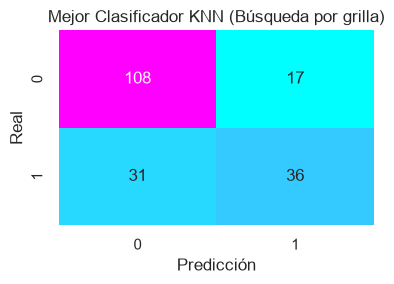

In [5]:
best_knn_grid = grid.best_estimator_

y_pred = best_knn_grid.predict(X_test)
cm_best_knn_grid = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_best_knn_grid, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Mejor Clasificador KNN (Búsqueda por grilla)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [6]:
# Midamos varias métricas:
print("Mejor Clasificador KNN (Búsqueda por grilla)")
P = np.sum(cm_best_knn_grid[1, :])
N = np.sum(cm_best_knn_grid[0, :])
TP = cm_best_knn_grid[1, 1]
TN = cm_best_knn_grid[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Mejor Clasificador KNN (Búsqueda por grilla)
Sensibilidad: 0.5373134328358209
Especificidad: 0.864
Exactitud balanceada: 0.7006567164179105
Precision: 0.6792452830188679
Recuperación: 0.5373134328358209
F1-score: 0.6


Por otro lado, la búsqueda aleatoria selecciona aleatoriamente combinaciones de hiperparámetros para evaluar el rendimiento del modelo. Aunque esta estrategia es menos 
costosa computacionalmente que la búsqueda de grilla, puede ser menos efectiva para explorar el espacio de hiper-parámetros de manera sistemática.

Usemos la búsqueda aleatoria que nos ofrece [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) y aprovechemos que buscamos menos a ampliar la grilla de hiper-parámetros:

In [7]:
from sklearn.model_selection import RandomizedSearchCV

classifier_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

hyperparams = {"model__n_neighbors": np.arange(1, 100),
               "model__weights": ["uniform", "distance"],
               "model__p": np.arange(1.0, 100.0)}

grid_random = RandomizedSearchCV(classifier_knn,
    hyperparams,
    n_iter=1800,
    refit=True,
    cv=3,
    scoring='f1',
    n_jobs=-1)

grid_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__n_neighbors': array([ 1, 2..., 97, 98, 99]), 'model__p': array([ 1., ...7., 98., 99.]), 'model__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",1800
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examp

In [8]:
grid_random.best_params_

{'model__weights': 'distance',
 'model__p': np.float64(4.0),
 'model__n_neighbors': np.int64(3)}

El resultado que encuentre aqui puede ser muy diferente cada vez que se ejecuta. Veamos el mejor modelo, que resultado nos da:

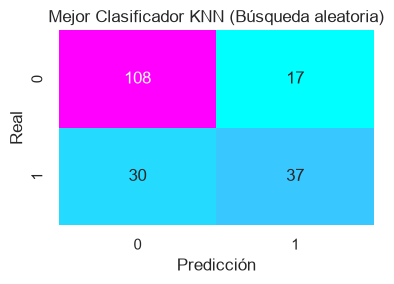

In [9]:
best_knn_grid_random = grid_random.best_estimator_

y_pred = best_knn_grid_random.predict(X_test)
cm_best_knn_grid_random = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_best_knn_grid_random, annot=True, fmt="d", cmap="cool", cbar=False, 
    ax=ax)
ax.set_title("Mejor Clasificador KNN (Búsqueda aleatoria)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [10]:
# Midamos varias métricas:
print("Mejor Clasificador KNN (Búsqueda aleatoria)")
P = np.sum(cm_best_knn_grid_random[1, :])
N = np.sum(cm_best_knn_grid_random[0, :])
TP = cm_best_knn_grid_random[1, 1]
TN = cm_best_knn_grid_random[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Mejor Clasificador KNN (Búsqueda aleatoria)
Sensibilidad: 0.5522388059701493
Especificidad: 0.864
Exactitud balanceada: 0.7081194029850746
Precision: 0.6851851851851852
Recuperación: 0.5522388059701493
F1-score: 0.6115702479338843


Ambos enfoques tienen sus ventajas y desventajas, y la elección entre ellos dependerá del tamaño del espacio de hiperparámetros, los recursos computacionales disponibles y la naturaleza del problema de machine learning que se está abordando.

---
## Comparativa final

Comparamos los dos modelos encontrados por la búsqueda de hiperparámetros contra un **baseline heurístico** derivado del análisis exploratorio de datos.

El EDA reveló que `glucosa` es el predictor más discriminativo del dataset (correlación de 0.47 con el target y la mayor separación visual entre clases). El baseline consiste en una regla simple:

> **Predecir diabetes si la glucosa supera el punto medio entre las medianas de ambas clases.**

Esta heurística no requiere entrenamiento ni hiperparámetros — representa el mínimo esperable antes de usar un modelo de ML.

In [11]:
from sklearn.metrics import balanced_accuracy_score

# Baseline: umbral de glucosa (columna 1 en X)
glucosa_sin_diabetes = pima_df.loc[pima_df["diabetes"] == 0, "glucosa"]
glucosa_con_diabetes = pima_df.loc[pima_df["diabetes"] == 1, "glucosa"]

umbral_glucosa = (glucosa_sin_diabetes.median() + glucosa_con_diabetes.median()) / 2

print(f"Mediana glucosa — sin diabetes: {glucosa_sin_diabetes.median():.1f} mg/dL")
print(f"Mediana glucosa — con diabetes: {glucosa_con_diabetes.median():.1f} mg/dL")
print(f"Umbral elegido:                 {umbral_glucosa:.1f} mg/dL")

y_pred_baseline = (X_test[:, 1] > umbral_glucosa).astype(int)

Mediana glucosa — sin diabetes: 107.0 mg/dL
Mediana glucosa — con diabetes: 140.0 mg/dL
Umbral elegido:                 123.5 mg/dL


In [12]:
y_pred_grid   = best_knn_grid.predict(X_test)
y_pred_random = best_knn_grid_random.predict(X_test)

modelos = ["Baseline (umbral glucosa)", "Grid Search (KNN)", "Random Search (KNN)"]
preds   = [y_pred_baseline, y_pred_grid, y_pred_random]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds],
}, index=modelos)

df_cmp.round(4)

,F1-score,Exactitud balanceada,Precisión,Recall
Baseline (umbral glucosa),0.6533,0.7297,0.5904,0.7313
Grid Search (KNN),0.6000,0.7007,0.6792,0.5373
Random Search (KNN),0.6116,0.7081,0.6852,0.5522


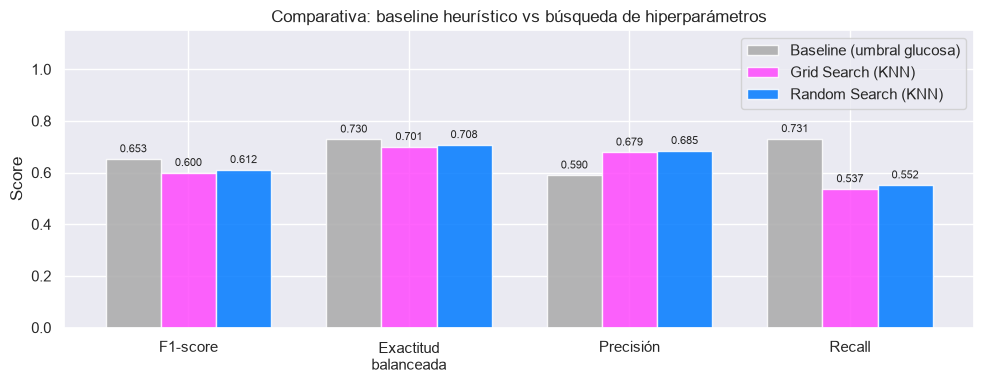

In [13]:
colores = ["#aaaaaa", "#ff48fd", "#007aff"]
metric_labels = ["F1-score", "Exactitud\nbalanceada", "Precisión", "Recall"]
x = np.arange(len(metric_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
for i, (modelo, color) in enumerate(zip(modelos, colores)):
    bars = ax.bar(
        x + (i - 1) * width,
        df_cmp.iloc[i],
        width,
        label=modelo.replace("\n", " "),
        color=color,
        alpha=0.85,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.set_title("Comparativa: baseline heurístico vs búsqueda de hiperparámetros")
ax.legend()
plt.tight_layout()
plt.show()